## Robótica y percepción computacional: Práctica análisis de imagen (Segunda tarea)
**Autores:** Lucia Fuentes González (210229) , Tania Mobasser Aslfakouri (220299) y Miriam Bernat Jimenez (210162) 

In [8]:
import imageio as iio
import numpy as np
import cv2
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D as ax3d
%matplotlib inline

In [9]:
# Funcion que aplica la normalizacion rg a una imagen
# Divide el valor RGB de cada pixel por la suma de las tres componentes

def normaliza_rg(im):
    im_float = im.astype(np.float64)
    suma = im_float.sum(axis=2, keepdims=True)
    suma[suma == 0] = 1.0
    return im_float / suma

In [13]:
# Lee un video y genera otro con los canales de color normalizados

video_entrada = 'videos/video2017-4.avi'
video_salida = 'videos/video_normalizado_rg.avi'

cap = cv2.VideoCapture(video_entrada)
fps = cap.get(cv2.CAP_PROP_FPS)
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

out = cv2.VideoWriter(video_salida, cv2.VideoWriter_fourcc(*'XVID'), fps, (w, h))

while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame_norm = normaliza_rg(frame)
    out.write((frame_norm * 255).astype(np.uint8))

cap.release()
out.release()
print('Video normalizado guardado en:', video_salida)

Video normalizado guardado en: videos/video_normalizado_rg.avi


In [11]:
# Funcion que recibe la imagen original y la imagen marcada y genera
# graficos con la distribucion de colores de marca, linea y suelo
# para la imagen original y la obtenida de la normalizacion rg

def graficar_distribuciones(imOriginal, markImg):
    mk = markImg[:, :, :3]

    # Almaceno los valores RGB de 'imOriginal' que fueron marcados en 'markImg'
    mask_marca = (mk[:,:,0] == 255) & (mk[:,:,1] == 0) & (mk[:,:,2] == 0)
    mask_fondo = (mk[:,:,0] == 0) & (mk[:,:,1] == 255) & (mk[:,:,2] == 0)
    mask_linea = (mk[:,:,0] == 0) & (mk[:,:,1] == 0) & (mk[:,:,2] == 255)

    data_marca = imOriginal[mask_marca]  # datos marcados en rojo
    data_fondo = imOriginal[mask_fondo]  # datos marcados en verde
    data_linea = imOriginal[mask_linea]  # datos marcados en azul

    # Pinto los datos RGB
    fig = plt.figure()
    ax = fig.add_subplot(projection='3d')

    ax.plot(data_marca[:,0],data_marca[:,1],data_marca[:,2],'r.',label='marca')
    ax.plot(data_fondo[:,0],data_fondo[:,1],data_fondo[:,2],'g.',label='fondo')
    ax.plot(data_linea[:,0],data_linea[:,1],data_linea[:,2],'b.',label='linea')
    ax.set_xlabel('R Label')
    ax.set_ylabel('G Label')
    ax.set_zlabel('B Label')
    ax.legend()
    plt.title('Espacio RGB')
    plt.show()

    # Ahora hago lo mismo con los datos normalizados segun la 'normalizacion rgb'
    imrgbn = normaliza_rg(imOriginal)

    data_marca_n = imrgbn[mask_marca]  # datos marcados en rojo
    data_fondo_n = imrgbn[mask_fondo]  # datos marcados en verde
    data_linea_n = imrgbn[mask_linea]  # datos marcados en azul

    plt.figure()
    plt.plot(data_marca_n[:,0],data_marca_n[:,1],'r.',label='marca')
    plt.plot(data_fondo_n[:,0],data_fondo_n[:,1],'g.',label='fondo')
    plt.plot(data_linea_n[:,0],data_linea_n[:,1],'b.',label='linea')
    plt.title('Espacio RGB normalizado')
    plt.legend()
    plt.show()

C:\Users\miria\AppData\Local\Temp\ipykernel_9996\2886035744.py:2: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  imNp = iio.imread('images/001.png')
C:\Users\miria\AppData\Local\Temp\ipykernel_9996\2886035744.py:3: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  markImg = iio.imread('images/001_mark.png')


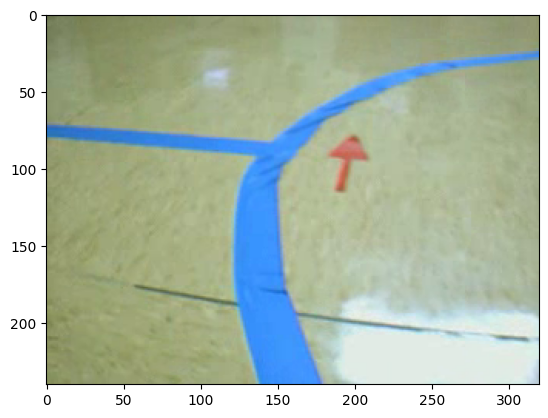

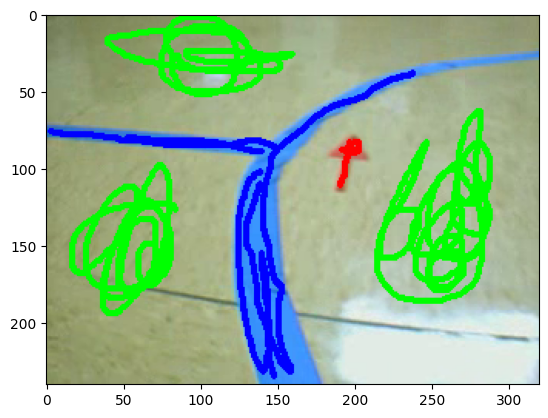

In [14]:
# Leo las imagenes de entrenamiento
imNp = iio.imread('images/001.png')
markImg = iio.imread('images/001_mark.png')
plt.imshow(imNp)
plt.show()
plt.imshow(markImg)
plt.show()

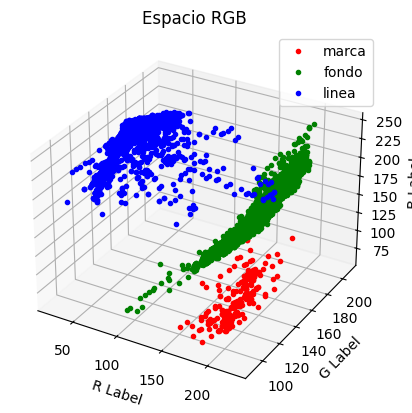

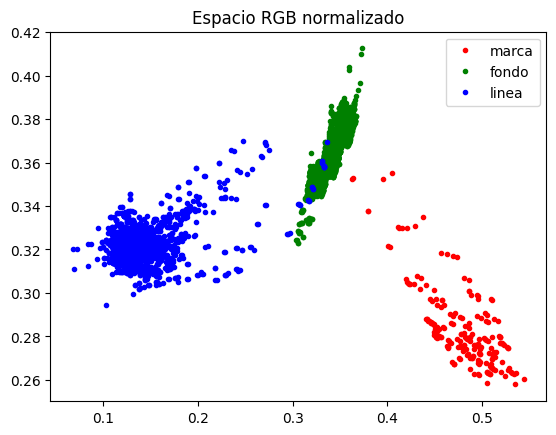

In [15]:
graficar_distribuciones(imNp, markImg)